In [ ]:
import requests
import pandas as pd

BASE_URL = "https://data.cms.gov/data-api/v1/dataset/9552739e-3d05-4c1b-8eff-ecabf391e2e5/data"

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

resp = requests.get(BASE_URL, params={"size": 200}, timeout=60)
resp.raise_for_status()

df = pd.DataFrame(resp.json())
df.head()

In [ ]:
df.columns.tolist()


In [ ]:
# Check the shape of the DataFrame
df.shape

In [ ]:
df.info()

In [ ]:
numeric_cols = [
    "Tot_Clms",
    "Tot_30day_Fills",
    "Tot_Day_Suply",
    "Tot_Drug_Cst",
    "Tot_Benes",
    "GE65_Tot_Clms",
    "GE65_Tot_30day_Fills",
    "GE65_Tot_Drug_Cst",
    "GE65_Tot_Day_Suply",
    "GE65_Tot_Benes"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [ ]:
df[numeric_cols].dtypes

In [ ]:
# Check for missing values
df.isna().sum().sort_values(ascending=False).head(30)

In [ ]:
df.nunique().sort_values()

In [ ]:
# CMS documents /data/stats for total rows.
stats_url = BASE_URL + "/stats"
stats_resp = requests.get(stats_url, timeout=60)
stats_resp.raise_for_status()

stats = stats_resp.json()
stats

In [ ]:
stats.get("total_rows")

In [ ]:
df[[
    "Prscrbr_NPI",
    "Prscrbr_Last_Org_Name",
    "Prscrbr_First_Name",
    "Prscrbr_State_Abrvtn",
    "Prscrbr_Type",
    "Brnd_Name",
    "Gnrc_Name",
    "Tot_Clms",
    "Tot_30day_Fills",
    "Tot_Drug_Cst",
    "Tot_Benes"
]].head(10)

In [ ]:
df[["Tot_Clms", "Tot_30day_Fills", "Tot_Day_Suply", "Tot_Drug_Cst", "Tot_Benes"]].describe()

In [ ]:
#Since CMS allows up to 5,000 rows per request, use that for exploration
sample_params = {
    "size": 5000,
    "offset": 0
}

sample_resp = requests.get(BASE_URL, params=sample_params, timeout=60)
sample_resp.raise_for_status()

sample_df = pd.DataFrame(sample_resp.json())
sample_df.shape

In [ ]:
#convert numeric columns in sample_df to numeric types
for col in numeric_cols:
    if col in sample_df.columns:
        sample_df[col] = pd.to_numeric(sample_df[col], errors="coerce")

In [ ]:
#Total drugs by total Cost
sample_df.groupby("Brnd_Name", dropna=False)["Tot_Drug_Cst"] \
    .sum() \
    .sort_values(ascending=False) \
    .head(20)

In [ ]:
#Total generic drugs by total Cost
sample_df.groupby("Gnrc_Name", dropna=False)["Tot_Drug_Cst"] \
    .sum() \
    .sort_values(ascending=False) \
    .head(20)

In [ ]:
#Top specialties by total Cost
sample_df.groupby("Prscrbr_Type", dropna=False)["Tot_Drug_Cst"] \
    .sum() \
    .sort_values(ascending=False) \
    .head(20)

In [ ]:
#Top states by total Cost
sample_df.groupby("Prscrbr_State_Abrvtn", dropna=False)["Tot_Drug_Cst"] \
    .sum() \
    .sort_values(ascending=False) \
    .head(20)


In [ ]:
def fetch_data(size=1000, offset=0, sort=None, filters=None):
    params = {
        "size": size,
        "offset": offset
    }
    if sort:
        params["sort"] = sort
    if filters:
        params.update(filters)

    resp = requests.get(BASE_URL, params=params, timeout=60)
    resp.raise_for_status()

    df = pd.DataFrame(resp.json())

    numeric_cols = [
        "Tot_Clms",
        "Tot_30day_Fills",
        "Tot_Day_Suply",
        "Tot_Drug_Cst",
        "Tot_Benes",
        "GE65_Tot_Clms",
        "GE65_Tot_30day_Fills",
        "GE65_Tot_Drug_Cst",
        "GE65_Tot_Day_Suply",
        "GE65_Tot_Benes"
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.replace(",", "", regex=False)
                .str.replace("$", "", regex=False)
                .str.strip()
            )
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

In [ ]:
top_cost_df = fetch_data(size=30, sort="-Tot_Drug_Cst")
top_cost_df.shape
top_cost_df[[
    "Prscrbr_NPI",
    "Prscrbr_Last_Org_Name",
    "Prscrbr_First_Name",
    "Brnd_Name",
    "Gnrc_Name",
    "Tot_Clms",
    "Tot_Drug_Cst"
]].head(30)

In [48]:
sample_df["Tot_Drug_Cst"] = pd.to_numeric(sample_df["Tot_Drug_Cst"], errors="coerce")
sample_df["Tot_Clms"] = pd.to_numeric(sample_df["Tot_Clms"], errors="coerce")
sample_df["Tot_Benes"] = pd.to_numeric(sample_df["Tot_Benes"], errors="coerce")

In [52]:
top_brand = (
    sample_df.groupby("Brnd_Name", dropna=False)[["Tot_Drug_Cst", "Tot_Clms", "Tot_Benes"]]
    .sum()
    .rename(columns={
        "Tot_Drug_Cst": "Total Drug Cost",
        "Tot_Clms": "Total Claims",
        "Tot_Benes": "Total Beneficiaries"
    })
    .assign(**{
        "Total Beneficiaries": lambda df: df["Total Beneficiaries"].astype(int)
    })
    .sort_values("Total Drug Cost", ascending=False)
)

top_brand.index.name = "Brand Name"
top_brand.head(20)



,Total Drug Cost,Total Claims,Total Beneficiaries
Brand Name,,,
Eliquis,3797959.61,4285,904
Ozempic,2327296.77,1546,312
Jardiance,1514547.00,1307,277
Biktarvy,1198561.91,282,35
Trulicity,1195323.41,766,109
Xarelto,1076177.01,1204,192
Hizentra,1068274.32,47,0
Januvia,867000.75,774,82
Entresto,818859.87,782,159


In [53]:
top_generic = (
    sample_df.groupby("Gnrc_Name", dropna=False)[["Tot_Drug_Cst", "Tot_Clms", "Tot_Benes"]]
    .sum()
    .rename(columns={
        "Tot_Drug_Cst": "Total Drug Cost",
        "Tot_Clms": "Total Claims",
        "Tot_Benes": "Total Beneficiaries"
    })
    .assign(**{
        "Total Beneficiaries": lambda df: df["Total Beneficiaries"].astype(int)
    })
    .sort_values("Total Drug Cost", ascending=False)
)

top_generic.index.name = "Generic Name"
top_generic.head(20)


,Total Drug Cost,Total Claims,Total Beneficiaries
Generic Name,,,
Apixaban,3797959.61,4285,904
Semaglutide,2645300.27,1746,339
Empagliflozin,1514547.00,1307,277
Bictegrav/Emtricit/Tenofov Ala,1198561.91,282,35
Dulaglutide,1195323.41,766,109
"Insulin Glargine,hum.Rec.Anlog",1176693.77,1709,344
Rivaroxaban,1076177.01,1204,192
Immun Glob G(Igg)/Pro/Iga 0-50,1068274.32,47,0
Sitagliptin Phosphate,867000.75,774,82


In [55]:
top_prescribers = (
    sample_df.groupby(
        ["Prscrbr_NPI", "Prscrbr_Last_Org_Name", "Prscrbr_First_Name", "Prscrbr_Type"],
        dropna=False
    )[["Tot_Drug_Cst", "Tot_Clms", "Tot_Benes"]]
    .sum()
    .sort_values("Tot_Drug_Cst", ascending=False)
)

top_prescribers.head(20)

,,,,Tot_Drug_Cst,Tot_Clms,Tot_Benes
Prscrbr_NPI,Prscrbr_Last_Org_Name,Prscrbr_First_Name,Prscrbr_Type,,,
1003008533,Sabodash,Valeriy,Neurology,2988446.16,4417,1123.0
1003007048,Fereidouni,Sam,Family Practice,2567458.75,7771,2414.0
1003006396,Rush,Michelle,Nurse Practitioner,2565369.88,1682,259.0
1003011800,Blomeier,Herman,Endocrinology,1838287.00,3026,728.0
1003009861,Banna,Moustafa,Cardiology,1425483.96,5294,1583.0
1003008715,Hinson,Janelle,Physician Assistant,1352181.50,1717,501.0
1003007907,Tavan,Emmanuel,Pulmonary Disease,1308193.98,1403,392.0
1003011214,Bajaj,Bhavandeep,Internal Medicine,1210323.31,10920,2515.0
1003010943,Koshy,Anoopa,Endocrinology,1153985.78,2187,508.0


In [57]:
detail_df = sample_df[[
    "Prscrbr_NPI",
    "Prscrbr_Last_Org_Name",
    "Prscrbr_First_Name",
    "Prscrbr_Type",
    "Prscrbr_State_Abrvtn",
    "Brnd_Name",
    "Gnrc_Name",
    "Tot_Clms",
    "Tot_Benes",
    "Tot_Drug_Cst"
]].copy().rename(columns={
    "Prscrbr_NPI": "Prescriber NPI",
    "Prscrbr_Last_Org_Name": "Prescriber Last Name / Org Name",
    "Prscrbr_First_Name": "Prescriber First Name",
    "Prscrbr_Type": "Prescriber Type",
    "Prscrbr_State_Abrvtn": "State",
    "Brnd_Name": "Brand Name",
    "Gnrc_Name": "Generic Name",
    "Tot_Clms": "Total Claims",
    "Tot_Benes": "Total Beneficiaries",
    "Tot_Drug_Cst": "Total Drug Cost"
})

detail_df.head(20)


,Prescriber NPI,Prescriber Last Name / Org Name,Prescriber First Name,Prescriber Type,State,Brand Name,Generic Name,Total Claims,Total Beneficiaries,Total Drug Cost
0,1003000126,Enkeshafi,Ardalan,Hospitalist,MD,Eliquis,Apixaban,13,NaN,8828.74
1,1003000126,Enkeshafi,Ardalan,Hospitalist,MD,Prednisone,Prednisone,14,14.0,54.98
2,1003000142,Khalil,Rashid,Anesthesiology,OH,Acetaminophen-Codeine,Acetaminophen With Codeine,43,12.0,491.38
3,1003000142,Khalil,Rashid,Anesthesiology,OH,Amitriptyline Hcl,Amitriptyline Hcl,35,15.0,471.01
4,1003000142,Khalil,Rashid,Anesthesiology,OH,Baclofen,Baclofen,55,23.0,796.10
5,1003000142,Khalil,Rashid,Anesthesiology,OH,Buprenorphine,Buprenorphine,16,NaN,6229.05
6,1003000142,Khalil,Rashid,Anesthesiology,OH,Cyclobenzaprine Hcl,Cyclobenzaprine Hcl,54,30.0,572.47
7,1003000142,Khalil,Rashid,Anesthesiology,OH,Dantrolene Sodium,Dantrolene Sodium,14,13.0,236.09
8,1003000142,Khalil,Rashid,Anesthesiology,OH,Diclofenac Sodium,Diclofenac Sodium,82,42.0,2423.34
9,1003000142,Khalil,Rashid,Anesthesiology,OH,Duloxetine Hcl,Duloxetine Hcl,27,14.0,337.43


In [61]:
sample_df["Drug_Display"] = sample_df["Brnd_Name"].fillna("").str.strip()

sample_df.loc[
    sample_df["Drug_Display"] == "",
    "Drug_Display"
] = sample_df["Gnrc_Name"]

In [62]:
top_drugs = (
    sample_df.groupby("Drug_Display")[["Tot_Drug_Cst", "Tot_Clms"]]
    .sum()
    .rename(columns={
        "Tot_Drug_Cst": "Total Drug Cost ($)",
        "Tot_Clms": "Total Claims"
    })
    .sort_values("Total Drug Cost ($)", ascending=False)
)

top_drugs.head(20)

,Total Drug Cost ($),Total Claims
Drug_Display,,
Eliquis,3797959.61,4285
Ozempic,2327296.77,1546
Jardiance,1514547.00,1307
Biktarvy,1198561.91,282
Trulicity,1195323.41,766
Xarelto,1076177.01,1204
Hizentra,1068274.32,47
Januvia,867000.75,774
Entresto,818859.87,782


In [ ]:
top_drugs.style.format({
    "Total Drug Cost ($)": "${:,.0f}",
    "Total Claims": "{:,.0f}"
})

In [64]:
top_drugs = top_drugs.reset_index().rename(columns={
    "Drug_Display": "Drug"
})

top_drugs.head(20)

,Drug,Total Drug Cost ($),Total Claims
0,Eliquis,3797959.61,4285
1,Ozempic,2327296.77,1546
2,Jardiance,1514547.00,1307
3,Biktarvy,1198561.91,282
4,Trulicity,1195323.41,766
5,Xarelto,1076177.01,1204
6,Hizentra,1068274.32,47
7,Januvia,867000.75,774
8,Entresto,818859.87,782
9,Lantus Solostar,814405.76,1186


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

annual_files = sorted(Path(".").glob("MUP_DPR_20[0-9][0-9].csv"))

if not annual_files:
    raise FileNotFoundError(
        "No annual Part D CSV files found. Expected files like MUP_DPR_2021.csv."
    )

def summarize_drug_costs_by_year(csv_path, chunksize=250_000):
    year = int(csv_path.stem.split("_")[-1])
    chunk_totals = []

    for chunk in pd.read_csv(
        csv_path,
        usecols=["Brnd_Name", "Gnrc_Name", "Tot_Drug_Cst"],
        chunksize=chunksize,
        low_memory=False,
    ):
        brand = chunk["Brnd_Name"].fillna("").str.strip()
        generic = chunk["Gnrc_Name"].fillna("").str.strip()
        chunk["Drug"] = brand.mask(brand.eq(""), generic)
        chunk = chunk.loc[chunk["Drug"].ne("")].copy()
        chunk["Tot_Drug_Cst"] = pd.to_numeric(
            chunk["Tot_Drug_Cst"],
            errors="coerce"
        ).fillna(0)

        chunk_totals.append(
            chunk.groupby("Drug", as_index=False)["Tot_Drug_Cst"].sum()
        )

    year_df = (
        pd.concat(chunk_totals, ignore_index=True)
        .groupby("Drug", as_index=False)["Tot_Drug_Cst"]
        .sum()
    )
    year_df["Year"] = year
    return year_df

yearly_drug_costs = pd.concat(
    [summarize_drug_costs_by_year(csv_path) for csv_path in annual_files],
    ignore_index=True
)

top_10_drugs = (
    yearly_drug_costs.groupby("Drug", as_index=False)["Tot_Drug_Cst"]
    .sum()
    .nlargest(10, "Tot_Drug_Cst")
    .rename(columns={"Tot_Drug_Cst": "Combined Drug Cost ($)"})
)

grouped_cost_df = (
    yearly_drug_costs[yearly_drug_costs["Drug"].isin(top_10_drugs["Drug"])]
    .pivot(index="Drug", columns="Year", values="Tot_Drug_Cst")
    .fillna(0)
)

grouped_cost_df = grouped_cost_df.loc[top_10_drugs["Drug"]]
grouped_cost_df.index.name = "Drug"

grouped_cost_df

Year,2021,2022,2023
Drug,,,
Eliquis,1.189957e+10,1.444361e+10,1.739216e+10
Trulicity,4.156252e+09,5.581472e+09,6.666365e+09
Jardiance,3.186646e+09,5.148228e+09,8.031744e+09
Xarelto,4.581250e+09,5.042545e+09,5.511694e+09
Ozempic,2.206281e+09,4.040317e+09,8.535566e+09
Revlimid,5.574265e+09,5.575094e+09,3.437548e+09
Januvia,3.531951e+09,3.505634e+09,3.446734e+09
Humira(Cf) Pen,2.523314e+09,3.248734e+09,3.886300e+09
Trelegy Ellipta,2.100960e+09,2.971640e+09,4.011731e+09


In [5]:
grouped_cost_df.reset_index().style.format(
    {year: "${:,.0f}" for year in grouped_cost_df.columns}
)

Year,Drug,2021,2022,2023
0,Eliquis,"$11,899,569,359","$14,443,609,917","$17,392,162,956"
1,Trulicity,"$4,156,252,166","$5,581,472,136","$6,666,365,126"
2,Jardiance,"$3,186,646,442","$5,148,228,314","$8,031,744,087"
3,Xarelto,"$4,581,249,662","$5,042,544,922","$5,511,694,348"
4,Ozempic,"$2,206,280,892","$4,040,317,312","$8,535,565,766"
5,Revlimid,"$5,574,264,790","$5,575,093,999","$3,437,547,610"
6,Januvia,"$3,531,950,654","$3,505,633,729","$3,446,734,330"
7,Humira(Cf) Pen,"$2,523,313,723","$3,248,734,474","$3,886,299,635"
8,Trelegy Ellipta,"$2,100,960,349","$2,971,640,378","$4,011,731,370"
9,Lantus Solostar,"$2,480,164,657","$2,503,679,002","$2,763,668,436"


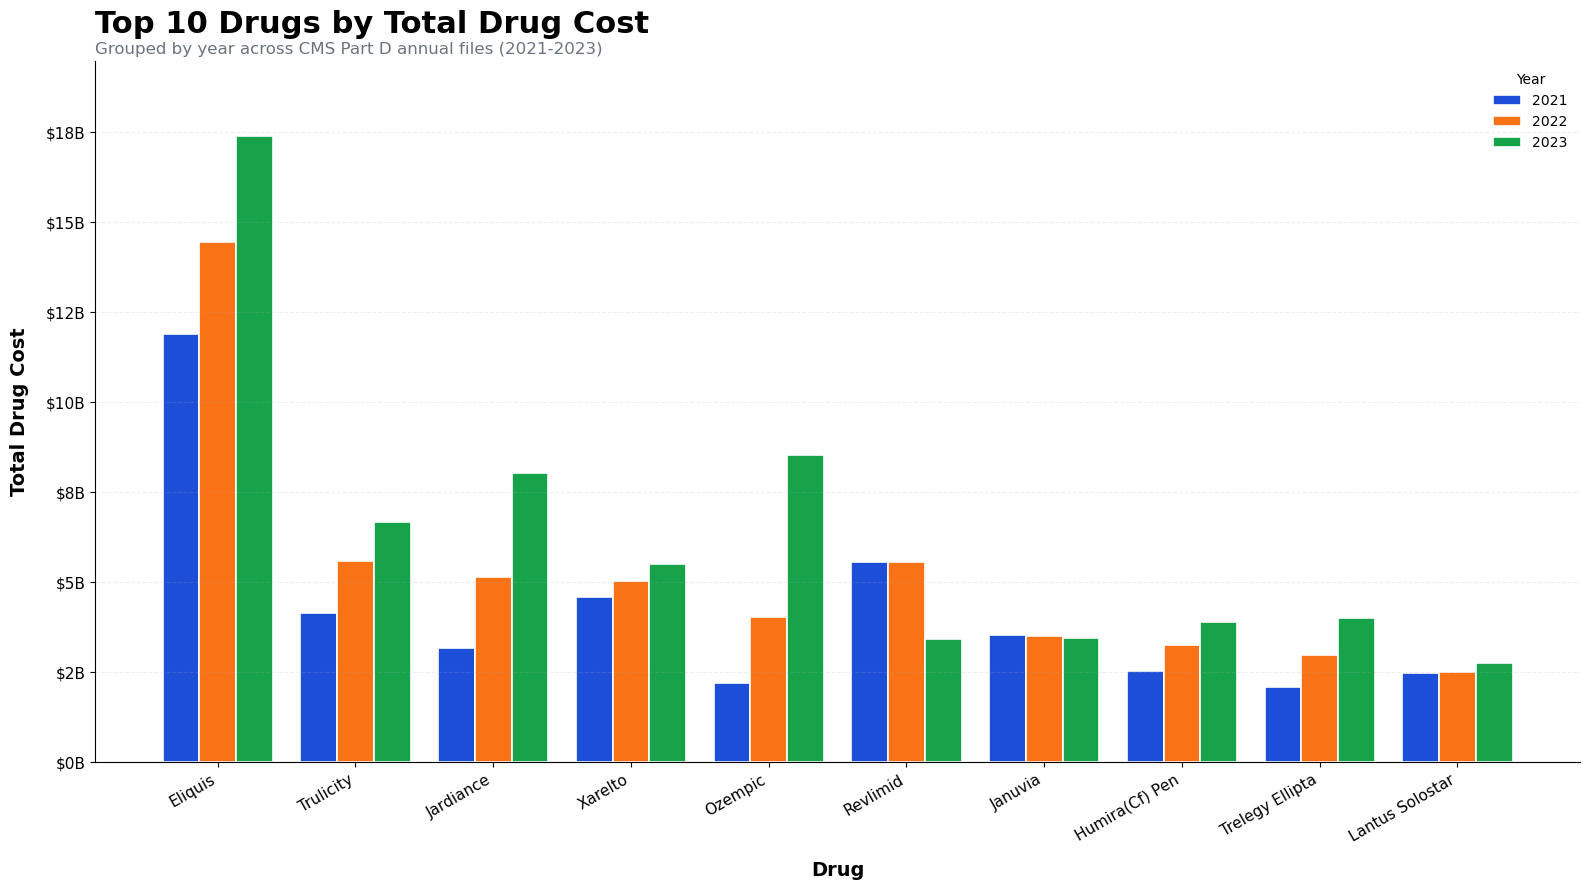

In [9]:
import matplotlib.ticker as mtick

plot_df = grouped_cost_df.reset_index()
years = list(grouped_cost_df.columns)
x = np.arange(len(plot_df))
width = 0.8 / len(years)
colors = ["#1D4ED8", "#F97316", "#16A34A", "#9333EA"]

fig, ax = plt.subplots(figsize=(16, 9), facecolor="white")
ax.set_facecolor("white")

max_val = grouped_cost_df.to_numpy().max()

for i, year in enumerate(years):
    offsets = x + (i - (len(years) - 1) / 2) * width
    ax.bar(
        offsets,
        plot_df[year],
        width=width,
        label=str(year),
        color=colors[i % len(colors)],
        edgecolor="white",
        linewidth=1.2
    )

ax.set_title(
    "Top 10 Drugs by Total Drug Cost",
    fontsize=22,
    fontweight="bold",
    loc="left",
    pad=20
)
ax.text(
    0,
    1.01,
    f"Grouped by year across CMS Part D annual files ({min(years)}-{max(years)})",
    transform=ax.transAxes,
    fontsize=12,
    color="#6B7280"
)

ax.set_xlabel("Drug", fontsize=14, fontweight="bold", labelpad=12)
ax.set_ylabel("Total Drug Cost", fontsize=14, fontweight="bold", labelpad=12)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Drug"], rotation=30, ha="right")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"${v/1e9:,.0f}B"))
ax.set_ylim(0, max_val * 1.12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.18)
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)
ax.legend(title="Year", frameon=False)

plt.tight_layout()
plt.show()


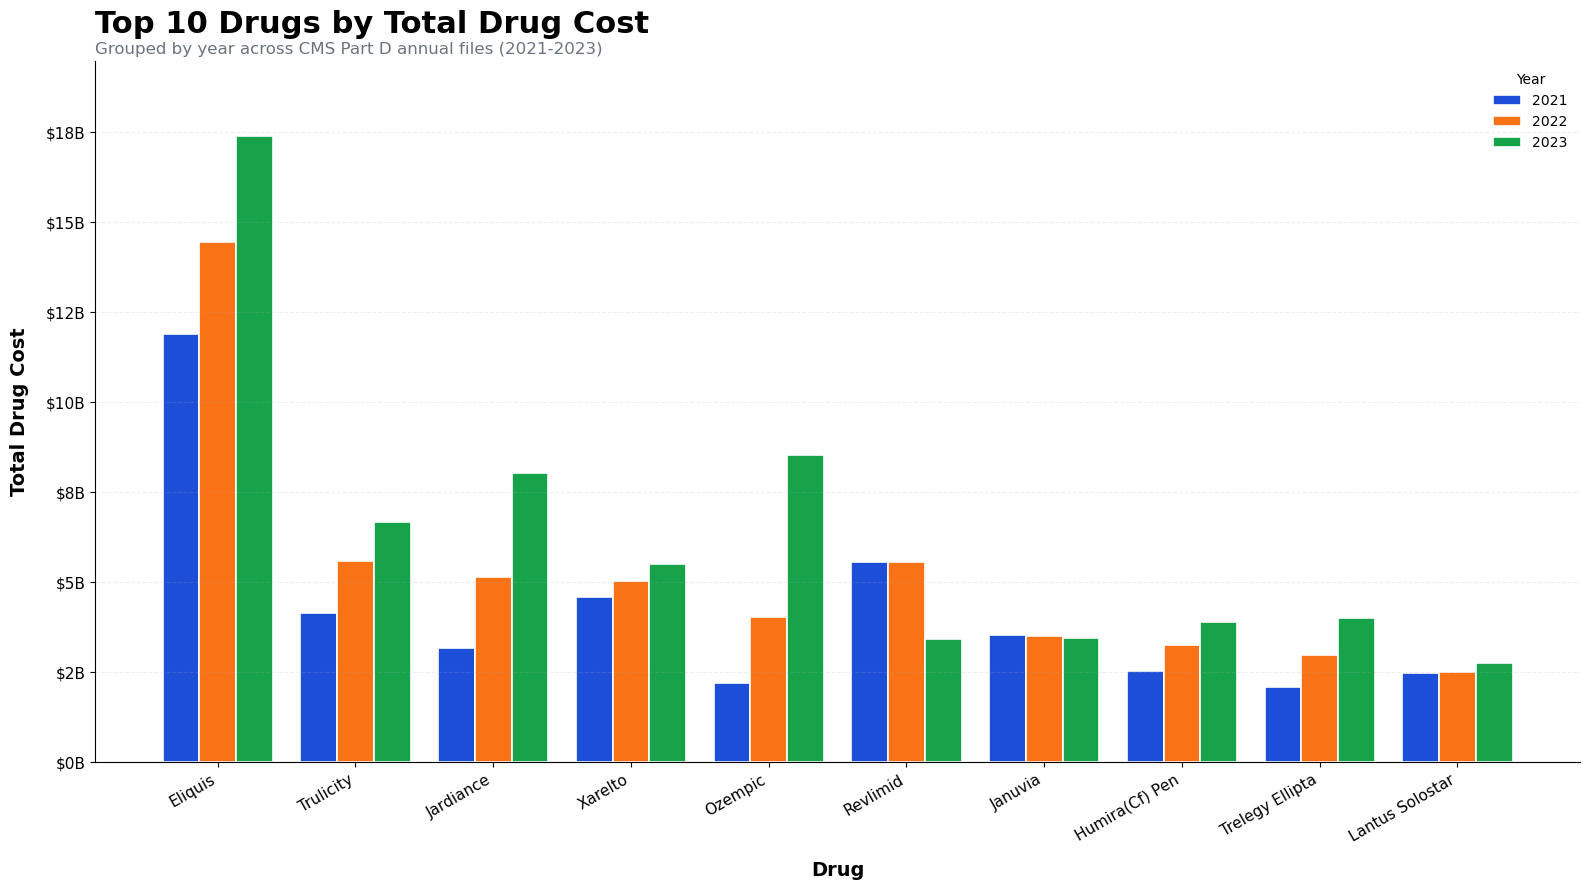

In [ ]:
import matplotlib.ticker as mtick

plot_df = grouped_cost_df.reset_index()
years = list(grouped_cost_df.columns)
x = np.arange(len(plot_df))
width = 0.8 / len(years)
colors = ["#1D4ED8", "#F97316", "#16A34A", "#9333EA"]

fig, ax = plt.subplots(figsize=(16, 9), facecolor="white")
ax.set_facecolor("white")

max_val = grouped_cost_df.to_numpy().max()

for i, year in enumerate(years):
    offsets = x + (i - (len(years) - 1) / 2) * width
    ax.bar(
        offsets,
        plot_df[year],
        width=width,
        label=str(year),
        color=colors[i % len(colors)],
        edgecolor="white",
        linewidth=1.2
    )

ax.set_title(
    "Top 10 Drugs by Total Drug Cost",
    fontsize=22,
    fontweight="bold",
    loc="left",
    pad=20
)
ax.text(
    0,
    1.01,
    f"Grouped by year across CMS Part D annual files ({min(years)}-{max(years)})",
    transform=ax.transAxes,
    fontsize=12,
    color="#6B7280"
)

ax.set_xlabel("Drug", fontsize=14, fontweight="bold", labelpad=12)
ax.set_ylabel("Total Drug Cost", fontsize=14, fontweight="bold", labelpad=12)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Drug"], rotation=30, ha="right")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"${v/1e9:,.0f}B"))
ax.set_ylim(0, max_val * 1.12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.18)
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)
ax.legend(title="Year", frameon=False)

plt.tight_layout()
plt.show()


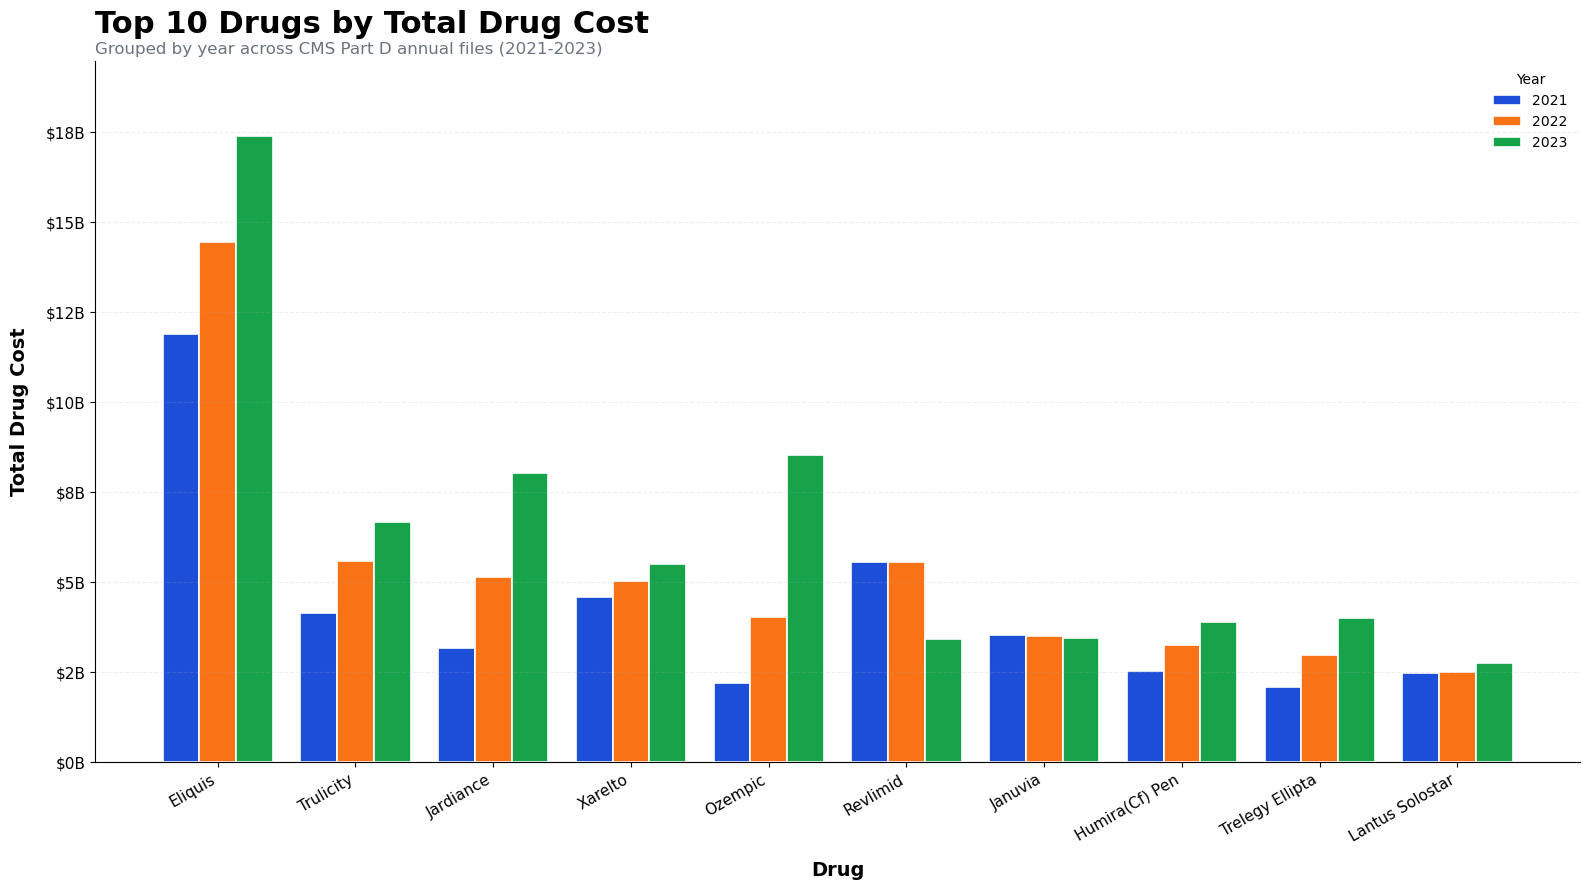

In [ ]:
import matplotlib.ticker as mtick

plot_df = grouped_cost_df.reset_index()
years = list(grouped_cost_df.columns)
x = np.arange(len(plot_df))
width = 0.8 / len(years)
colors = ["#1D4ED8", "#F97316", "#16A34A", "#9333EA"]

fig, ax = plt.subplots(figsize=(16, 9), facecolor="white")
ax.set_facecolor("white")

max_val = grouped_cost_df.to_numpy().max()

for i, year in enumerate(years):
    offsets = x + (i - (len(years) - 1) / 2) * width
    ax.bar(
        offsets,
        plot_df[year],
        width=width,
        label=str(year),
        color=colors[i % len(colors)],
        edgecolor="white",
        linewidth=1.2
    )

ax.set_title(
    "Top 10 Drugs by Total Drug Cost",
    fontsize=22,
    fontweight="bold",
    loc="left",
    pad=20
)
ax.text(
    0,
    1.01,
    f"Grouped by year across CMS Part D annual files ({min(years)}-{max(years)})",
    transform=ax.transAxes,
    fontsize=12,
    color="#6B7280"
)

ax.set_xlabel("Drug", fontsize=14, fontweight="bold", labelpad=12)
ax.set_ylabel("Total Drug Cost", fontsize=14, fontweight="bold", labelpad=12)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Drug"], rotation=30, ha="right")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"${v/1e9:,.0f}B"))
ax.set_ylim(0, max_val * 1.12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.18)
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)
ax.legend(title="Year", frameon=False)

plt.tight_layout()
plt.show()


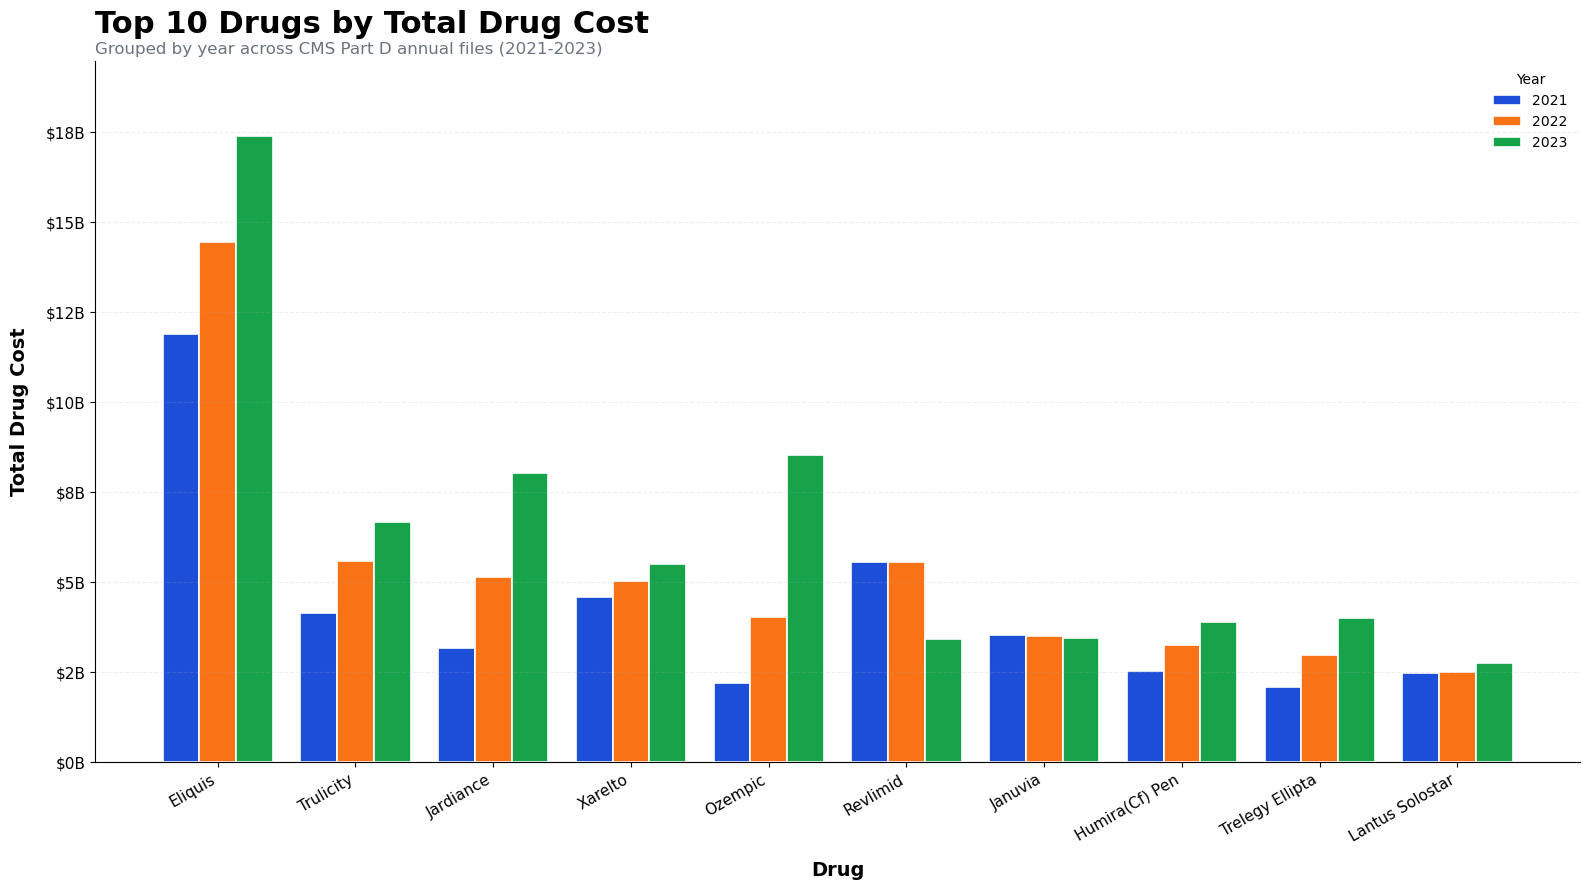

In [ ]:
import matplotlib.ticker as mtick

plot_df = grouped_cost_df.reset_index()
years = list(grouped_cost_df.columns)
x = np.arange(len(plot_df))
width = 0.8 / len(years)
colors = ["#1D4ED8", "#F97316", "#16A34A", "#9333EA"]

fig, ax = plt.subplots(figsize=(16, 9), facecolor="white")
ax.set_facecolor("white")

max_val = grouped_cost_df.to_numpy().max()

for i, year in enumerate(years):
    offsets = x + (i - (len(years) - 1) / 2) * width
    ax.bar(
        offsets,
        plot_df[year],
        width=width,
        label=str(year),
        color=colors[i % len(colors)],
        edgecolor="white",
        linewidth=1.2
    )

ax.set_title(
    "Top 10 Drugs by Total Drug Cost",
    fontsize=22,
    fontweight="bold",
    loc="left",
    pad=20
)
ax.text(
    0,
    1.01,
    f"Grouped by year across CMS Part D annual files ({min(years)}-{max(years)})",
    transform=ax.transAxes,
    fontsize=12,
    color="#6B7280"
)

ax.set_xlabel("Drug", fontsize=14, fontweight="bold", labelpad=12)
ax.set_ylabel("Total Drug Cost", fontsize=14, fontweight="bold", labelpad=12)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Drug"], rotation=30, ha="right")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"${v/1e9:,.0f}B"))
ax.set_ylim(0, max_val * 1.12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.18)
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)
ax.legend(title="Year", frameon=False)

plt.tight_layout()
plt.show()


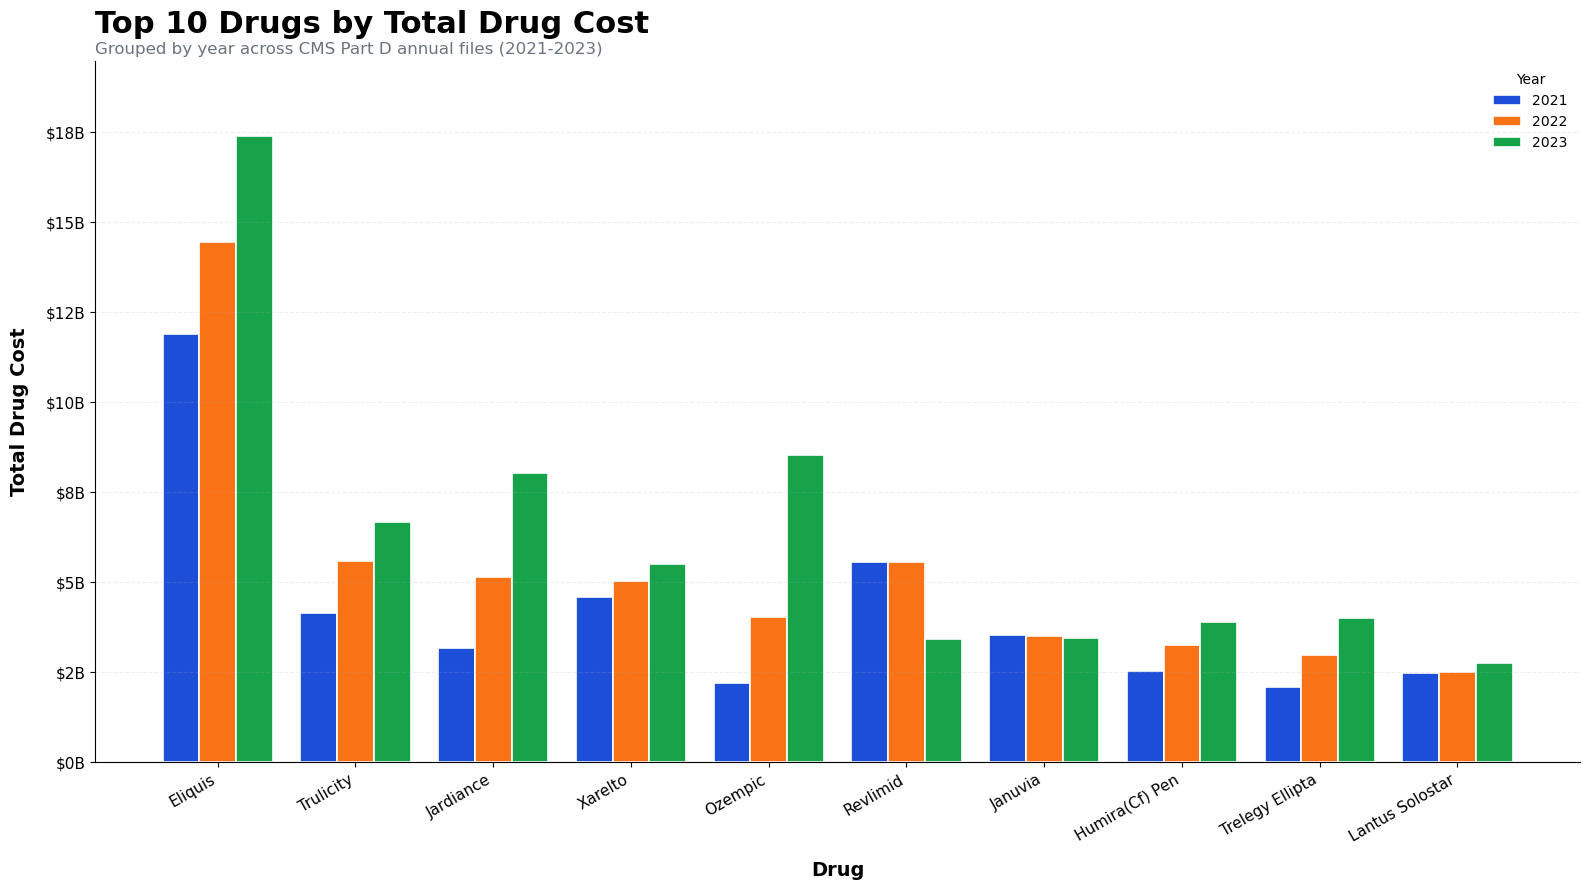

In [ ]:
import matplotlib.ticker as mtick

plot_df = grouped_cost_df.reset_index()
years = list(grouped_cost_df.columns)
x = np.arange(len(plot_df))
width = 0.8 / len(years)
colors = ["#1D4ED8", "#F97316", "#16A34A", "#9333EA"]

fig, ax = plt.subplots(figsize=(16, 9), facecolor="white")
ax.set_facecolor("white")

max_val = grouped_cost_df.to_numpy().max()

for i, year in enumerate(years):
    offsets = x + (i - (len(years) - 1) / 2) * width
    ax.bar(
        offsets,
        plot_df[year],
        width=width,
        label=str(year),
        color=colors[i % len(colors)],
        edgecolor="white",
        linewidth=1.2
    )

ax.set_title(
    "Top 10 Drugs by Total Drug Cost",
    fontsize=22,
    fontweight="bold",
    loc="left",
    pad=20
)
ax.text(
    0,
    1.01,
    f"Grouped by year across CMS Part D annual files ({min(years)}-{max(years)})",
    transform=ax.transAxes,
    fontsize=12,
    color="#6B7280"
)

ax.set_xlabel("Drug", fontsize=14, fontweight="bold", labelpad=12)
ax.set_ylabel("Total Drug Cost", fontsize=14, fontweight="bold", labelpad=12)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Drug"], rotation=30, ha="right")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"${v/1e9:,.0f}B"))
ax.set_ylim(0, max_val * 1.12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.18)
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)
ax.legend(title="Year", frameon=False)

plt.tight_layout()
plt.show()


In [81]:
import requests
from pathlib import Path

DATA_JSON_URL = "https://data.cms.gov/data.json"
DATASET_API_URL = "https://data.cms.gov/data-api/v1/dataset/9552739e-3d05-4c1b-8eff-ecabf391e2e5/data"
OUTPUT_FILE = Path("MUP_DPR_latest.csv")

# Find the dataset in CMS metadata
meta = requests.get(DATA_JSON_URL, timeout=60)
meta.raise_for_status()
catalog = meta.json()

dataset = next(
    ds for ds in catalog["dataset"]
    if any(
        dist.get("accessURL") == DATASET_API_URL
        for dist in ds.get("distribution", [])
    )
)

# Find the CSV distribution that corresponds to the same "latest" title as the API distribution
latest_api_dist = next(
    dist for dist in dataset["distribution"]
    if dist.get("format") == "API"
    and dist.get("accessURL") == DATASET_API_URL
    and dist.get("description") == "latest"
)

csv_dist = next(
    dist for dist in dataset["distribution"]
    if dist.get("mediaType") == "text/csv"
    and dist.get("title") == latest_api_dist.get("title")
)

csv_url = csv_dist["downloadURL"]
print("CSV URL:", csv_url)

# Download the CSV file
with requests.get(csv_url, stream=True, timeout=300) as r:
    r.raise_for_status()
    with OUTPUT_FILE.open("wb") as f:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)

print(f"Saved to {OUTPUT_FILE.resolve()}")


CSV URL: https://data.cms.gov/sites/default/files/2025-04/0d5915ce-002c-4d87-bde8-24ffb08bb6cc/MUP_DPR_RY25_P04_V10_DY23_NPIBN.csv
Saved to /Users/mohammad/Documents/GitHub/MedicarePartD/MUP_DPR_latest.csv


In [82]:
import pandas as pd

full_df = pd.read_csv("MUP_DPR_latest.csv")
full_df.head()


/var/folders/gx/wy7pmkg16hz6fx2gwctvnv500000gn/T/ipykernel_39584/3765469000.py:3: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  full_df = pd.read_csv("MUP_DPR_latest.csv")


,Prscrbr_NPI,Prscrbr_Last_Org_Name,Prscrbr_First_Name,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_State_FIPS,Prscrbr_Type,Prscrbr_Type_Src,Brnd_Name,Gnrc_Name,Tot_Clms,Tot_30day_Fills,Tot_Day_Suply,Tot_Drug_Cst,Tot_Benes,GE65_Sprsn_Flag,GE65_Tot_Clms,GE65_Tot_30day_Fills,GE65_Tot_Drug_Cst,GE65_Tot_Day_Suply,GE65_Bene_Sprsn_Flag,GE65_Tot_Benes
0,1003000126,Enkeshafi,Ardalan,Bethesda,MD,24,Hospitalist,Claim-Specialty,Eliquis,Apixaban,13,15.3,437,8828.74,NaN,#,NaN,NaN,NaN,NaN,*,NaN
1,1003000126,Enkeshafi,Ardalan,Bethesda,MD,24,Hospitalist,Claim-Specialty,Prednisone,Prednisone,14,14.0,153,54.98,14.0,#,NaN,NaN,NaN,NaN,#,NaN
2,1003000142,Khalil,Rashid,Toledo,OH,39,Anesthesiology,Claim-Specialty,Acetaminophen-Codeine,Acetaminophen With Codeine,43,43.0,1020,491.38,12.0,#,NaN,NaN,NaN,NaN,*,NaN
3,1003000142,Khalil,Rashid,Toledo,OH,39,Anesthesiology,Claim-Specialty,Amitriptyline Hcl,Amitriptyline Hcl,35,35.0,1050,471.01,15.0,#,NaN,NaN,NaN,NaN,*,NaN
4,1003000142,Khalil,Rashid,Toledo,OH,39,Anesthesiology,Claim-Specialty,Baclofen,Baclofen,55,63.0,1890,796.10,23.0,NaN,27.0,29.0,417.86,870.0,*,NaN


In [83]:
import pandas as pd

CSV_FILE = "MUP_DPR_latest.csv"

brand_totals = pd.Series(dtype="float64")

for chunk in pd.read_csv(
    CSV_FILE,
    usecols=["Brnd_Name", "Tot_Drug_Cst"],
    chunksize=500_000,
    low_memory=False
):
    chunk["Tot_Drug_Cst"] = pd.to_numeric(chunk["Tot_Drug_Cst"], errors="coerce")
    
    chunk_totals = (
        chunk.dropna(subset=["Brnd_Name"])
        .groupby("Brnd_Name")["Tot_Drug_Cst"]
        .sum()
    )
    
    brand_totals = brand_totals.add(chunk_totals, fill_value=0)

plot_df = (
    brand_totals.sort_values(ascending=False)
    .head(20)
    .reset_index()
)
plot_df.columns = ["Drug", "Total Drug Cost ($)"]

plot_df.head()


,Drug,Total Drug Cost ($)
0,Eliquis,1.739216e+10
1,Ozempic,8.535566e+09
2,Jardiance,8.031744e+09
3,Trulicity,6.666365e+09
4,Xarelto,5.511694e+09


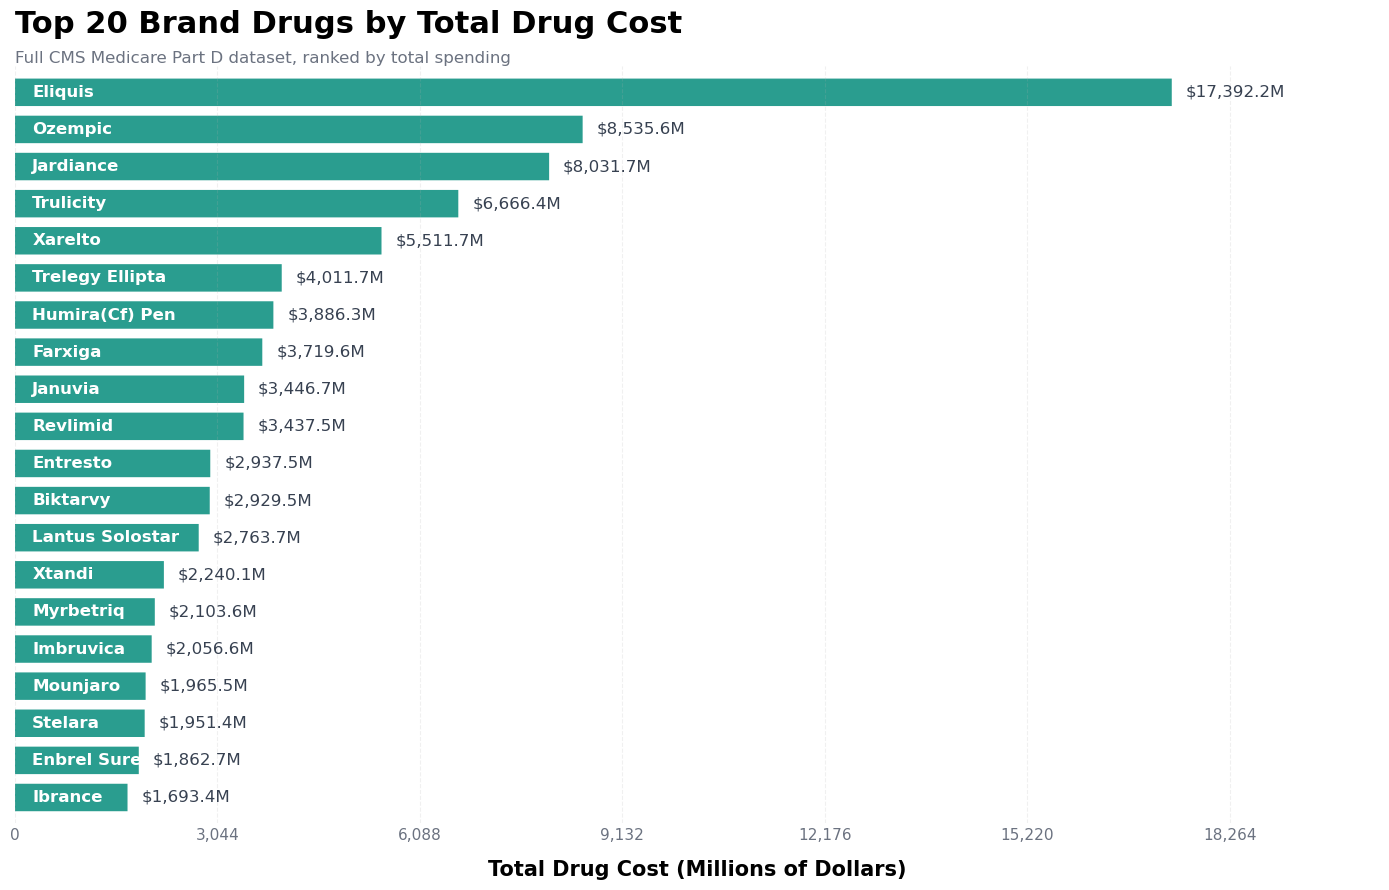

In [84]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyBboxPatch

bar_df = plot_df.sort_values("Total Drug Cost ($)", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 9), facecolor="white")
ax.set_facecolor("white")

y_pos = np.arange(len(bar_df))
bar_height = 0.72
bar_color = "#2A9D8F"

for y, value in zip(y_pos, bar_df["Total Drug Cost ($)"]):
    rounded_bar = FancyBboxPatch(
        (0, y - bar_height / 2),
        value,
        bar_height,
        boxstyle="round,pad=0.01,rounding_size=8",
        linewidth=0,
        facecolor=bar_color
    )
    ax.add_patch(rounded_bar)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.tick_params(axis="y", length=0, labelleft=False)
ax.tick_params(axis="x", length=0, labelsize=11, colors="#6B7280")
ax.grid(axis="x", linestyle="--", alpha=0.18)

ax.set_title(
    "Top 20 Brand Drugs by Total Drug Cost",
    fontsize=22,
    fontweight="bold",
    loc="left",
    pad=24
)
ax.text(
    0, 1.005,
    "Full CMS Medicare Part D dataset, ranked by total spending",
    transform=ax.transAxes,
    fontsize=12,
    color="#6B7280"
)

ax.set_xlabel(
    "Total Drug Cost (Millions of Dollars)",
    fontsize=15,
    fontweight="bold",
    labelpad=12
)

max_val = bar_df["Total Drug Cost ($)"].max()
ax.set_xlim(0, max_val * 1.18)

tick_max_m = int(np.ceil((max_val * 1.05) / 1e6))
tick_step = max(1, int(np.ceil(tick_max_m / 6)))
tick_vals_m = np.arange(0, tick_max_m + tick_step, tick_step)

ax.set_xticks(tick_vals_m * 1e6)
ax.set_xticklabels([f"{v:,}" for v in tick_vals_m])

for y, drug, value in zip(y_pos, bar_df["Drug"], bar_df["Total Drug Cost ($)"]):
    ax.text(
        max_val * 0.015,
        y,
        drug,
        va="center",
        ha="left",
        fontsize=12,
        fontweight="bold",
        color="white"
    )
    ax.text(
        value + max_val * 0.012,
        y,
        f"${value/1e6:,.1f}M",
        va="center",
        ha="left",
        fontsize=12,
        color="#374151"
    )

ax.set_yticks(y_pos)
ax.set_yticklabels([])
ax.set_ylim(-0.7, len(bar_df) - 0.3)

plt.tight_layout()
plt.show()


In [85]:
import requests
from pathlib import Path

DATA_JSON_URL = "https://data.cms.gov/data.json"
DATASET_API_URL = "https://data.cms.gov/data-api/v1/dataset/9552739e-3d05-4c1b-8eff-ecabf391e2e5/data"

def download_part_d_year_csv(year, output_dir="."):
    meta = requests.get(DATA_JSON_URL, timeout=60)
    meta.raise_for_status()
    catalog = meta.json()

    dataset = next(
        ds for ds in catalog["dataset"]
        if any(
            dist.get("accessURL") == DATASET_API_URL
            for dist in ds.get("distribution", [])
        )
    )

    # Match the annual CSV by temporal year
    csv_dist = next(
        dist for dist in dataset["distribution"]
        if dist.get("mediaType") == "text/csv"
        and dist.get("temporal", "").startswith(f"{year}-01-01/")
    )

    csv_url = csv_dist["downloadURL"]
    output_path = Path(output_dir) / f"MUP_DPR_{year}.csv"

    print(f"Downloading {year} from:")
    print(csv_url)

    with requests.get(csv_url, stream=True, timeout=300) as r:
        r.raise_for_status()
        with output_path.open("wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)

    print(f"Saved to {output_path.resolve()}")
    return output_path

# Download 2021 and 2022
file_2021 = download_part_d_year_csv(2021)
file_2022 = download_part_d_year_csv(2022)


https://data.cms.gov/sites/default/files/2024-05/43359391-e7fa-40b9-9bd4-5dc295e18712/MUP_DPR_RY24_P04_V10_DY21_NPIBN.csv
Saved to /Users/mohammad/Documents/GitHub/MedicarePartD/MUP_DPR_2021.csv
https://data.cms.gov/sites/default/files/2024-05/18f82097-61a6-4889-9941-9a0b6ad7523c/MUP_DPR_RY24_P04_V10_DY22_NPIBN.csv
Saved to /Users/mohammad/Documents/GitHub/MedicarePartD/MUP_DPR_2022.csv


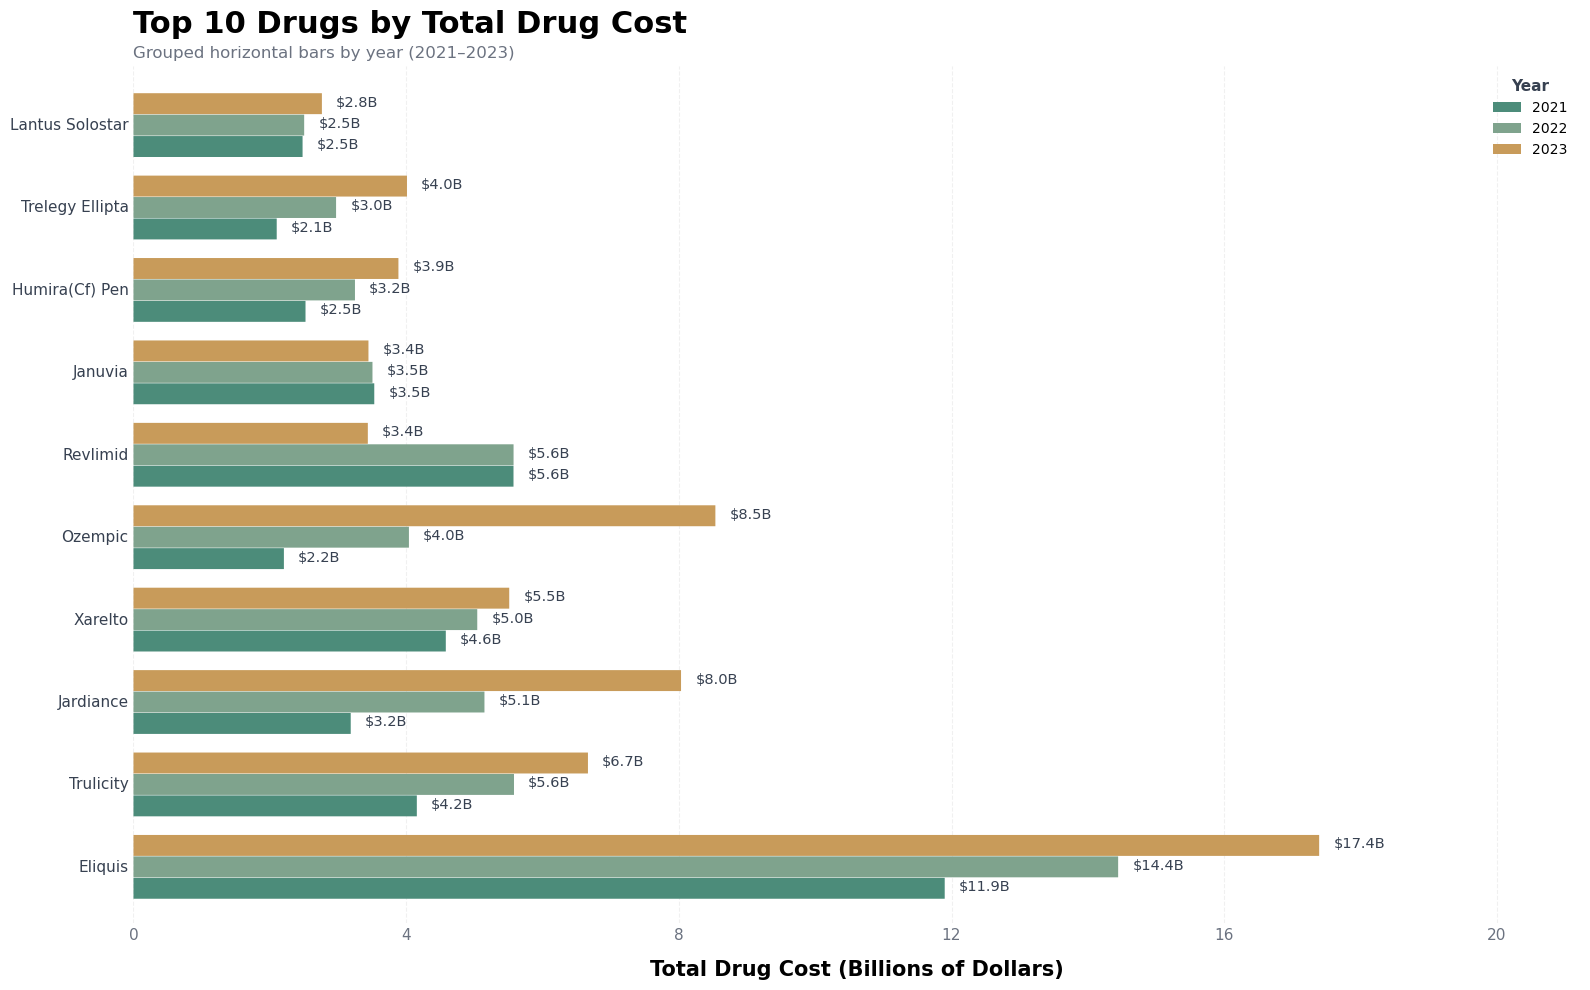

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Patch

# grouped_cost_df is expected to look like:
# index = Drug
# columns = years (e.g. 2021, 2022, 2023)
plot_df = grouped_cost_df.copy()
years = list(plot_df.columns)
drugs = plot_df.index.tolist()

# Layout
y_base = np.arange(len(drugs))
group_height = 0.78
bar_height = group_height / len(years)

# Matte palette
colors = [
    "#4C8C7A",  # matte teal
    "#7FA38D",  # sage
    "#C89B5A",  # muted ochre
    "#5E6B73",  # slate
    "#A06C5B",  # clay
]

fig, ax = plt.subplots(figsize=(16, 10), facecolor="white")
ax.set_facecolor("white")

max_val = plot_df.to_numpy().max()
rounding_size = bar_height * 0.35

for i, year in enumerate(years):
    color = colors[i % len(colors)]
    y_offsets = y_base + (i - (len(years) - 1) / 2) * bar_height

    for y, value in zip(y_offsets, plot_df[year]):
        rounded_bar = FancyBboxPatch(
            (0, y - bar_height / 2),
            value,
            bar_height * 0.9,
            boxstyle=f"round,pad=0.01,rounding_size={rounding_size}",
            linewidth=0,
            facecolor=color,
            zorder=3
        )
        ax.add_patch(rounded_bar)

        ax.text(
            value + max_val * 0.012,
            y,
            f"${value/1e9:,.1f}B",
            va="center",
            ha="left",
            fontsize=10.5,
            color="#374151"
        )

# Styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

ax.grid(axis="x", linestyle="--", alpha=0.18, zorder=0)
ax.tick_params(axis="x", length=0, labelsize=11, colors="#6B7280")
ax.tick_params(axis="y", length=0, labelsize=11, colors="#374151")

ax.set_title(
    "Top 10 Drugs by Total Drug Cost",
    fontsize=22,
    fontweight="bold",
    loc="left",
    pad=24
)
ax.text(
    0, 1.01,
    f"Grouped horizontal bars by year ({min(years)}–{max(years)})",
    transform=ax.transAxes,
    fontsize=12,
    color="#6B7280"
)

ax.set_xlabel(
    "Total Drug Cost (Billions of Dollars)",
    fontsize=15,
    fontweight="bold",
    labelpad=12
)

# X axis ticks in billions
tick_max_b = int(np.ceil((max_val * 1.05) / 1e9))
tick_step = max(1, int(np.ceil(tick_max_b / 6)))
tick_vals_b = np.arange(0, tick_max_b + tick_step, tick_step)

ax.set_xticks(tick_vals_b * 1e9)
ax.set_xticklabels([f"{v:,}" for v in tick_vals_b])

ax.set_yticks(y_base)
ax.set_yticklabels(drugs)
ax.set_ylim(-0.7, len(drugs) - 0.3)
ax.set_xlim(0, max_val * 1.22)

legend_handles = [
    Patch(facecolor=colors[i % len(colors)], edgecolor="none", label=str(year))
    for i, year in enumerate(years)
]
legend = ax.legend(
    handles=legend_handles,
    title="Year",
    frameon=False,
    loc="upper right"
)
plt.setp(legend.get_title(), fontsize=11, fontweight="bold", color="#374151")

plt.tight_layout()
plt.show()


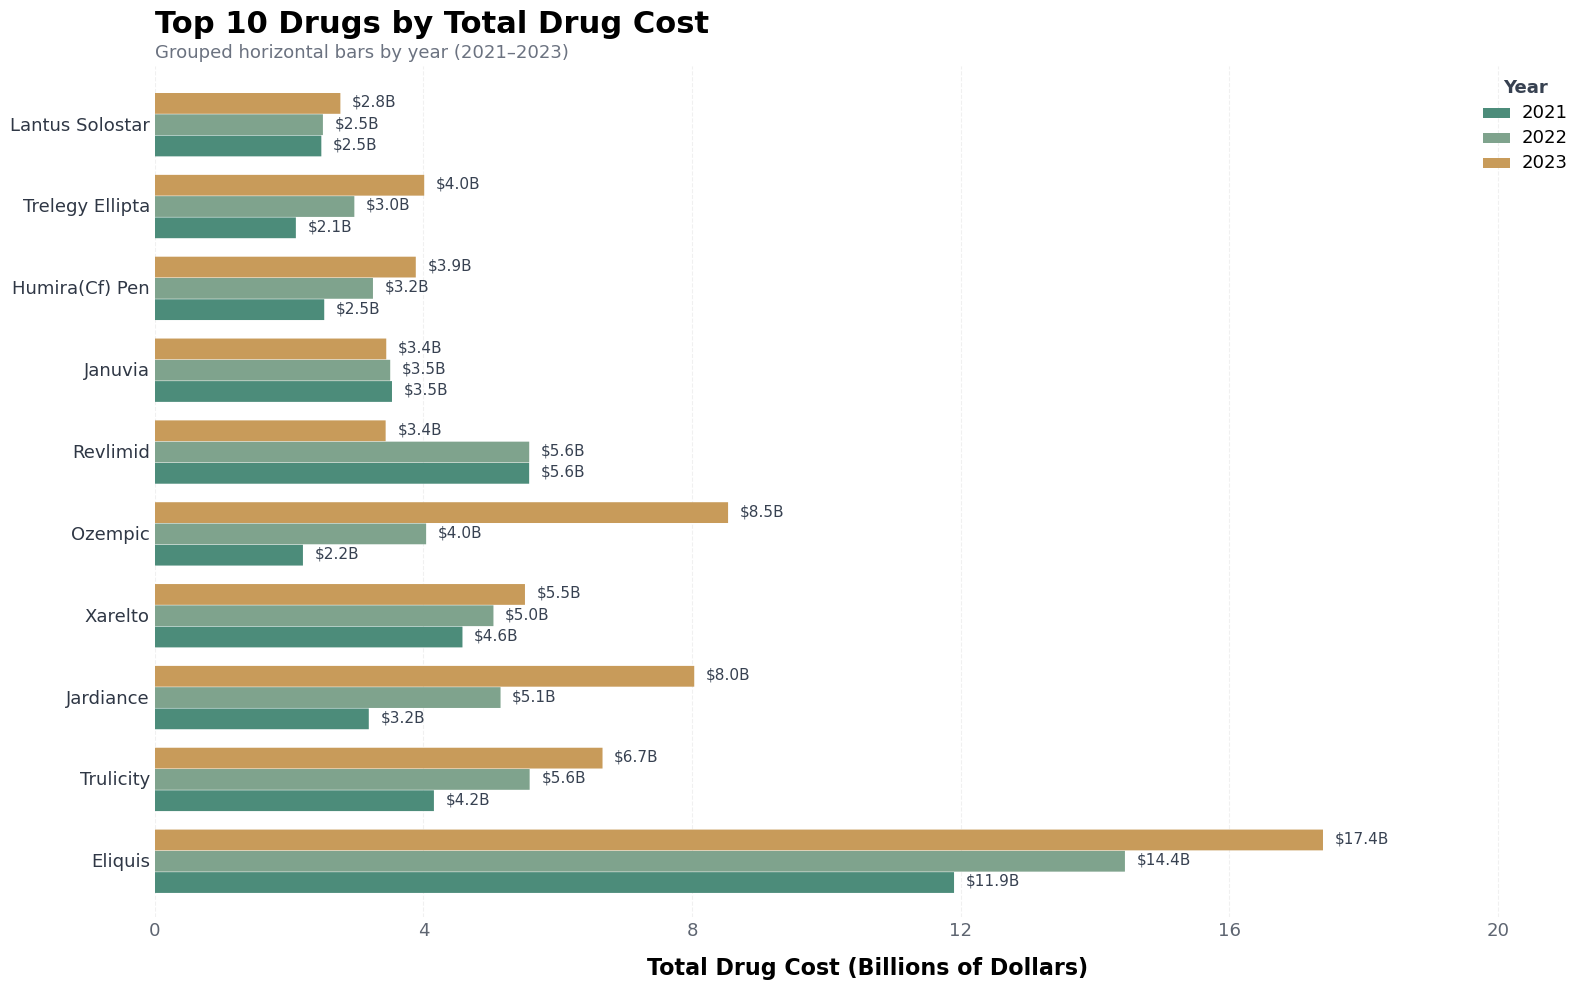

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Patch

plot_df = grouped_cost_df.copy()
years = list(plot_df.columns)
drugs = plot_df.index.tolist()

y_base = np.arange(len(drugs))
group_height = 0.78
bar_height = group_height / len(years)

colors = ["#4C8C7A", "#7FA38D", "#C89B5A", "#5E6B73"]

fig, ax = plt.subplots(figsize=(16, 10), facecolor="white")
ax.set_facecolor("white")

max_val = plot_df.to_numpy().max()
rounding_size = bar_height * 0.35

for i, year in enumerate(years):
    color = colors[i % len(colors)]
    y_offsets = y_base + (i - (len(years) - 1) / 2) * bar_height

    for y, value in zip(y_offsets, plot_df[year]):
        bar = FancyBboxPatch(
            (0, y - bar_height / 2),
            value,
            bar_height * 0.9,
            boxstyle=f"round,pad=0.01,rounding_size={rounding_size}",
            linewidth=0,
            facecolor=color,
            zorder=3
        )
        ax.add_patch(bar)

        ax.text(
            value + max_val * 0.01,
            y,
            f"${value/1e9:,.1f}B",
            va="center",
            ha="left",
            fontsize=11,
            color="#374151"
        )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

ax.grid(axis="x", linestyle="--", alpha=0.18, zorder=0)
ax.tick_params(axis="x", length=0, labelsize=13, colors="#5E6571")
ax.tick_params(axis="y", length=0, labelsize=13, colors="#2F3745")

ax.set_title(
    "Top 10 Drugs by Total Drug Cost",
    fontsize=22,
    fontweight="bold",
    loc="left",
    pad=24
)
ax.text(
    0, 1.01,
    f"Grouped horizontal bars by year ({min(years)}–{max(years)})",
    transform=ax.transAxes,
    fontsize=13,
    color="#6B7280"
)

ax.set_xlabel(
    "Total Drug Cost (Billions of Dollars)",
    fontsize=16,
    fontweight="bold",
    labelpad=12
)

tick_max_b = int(np.ceil((max_val * 1.05) / 1e9))
tick_step = max(1, int(np.ceil(tick_max_b / 6)))
tick_vals_b = np.arange(0, tick_max_b + tick_step, tick_step)

ax.set_xticks(tick_vals_b * 1e9)
ax.set_xticklabels([f"{v:,}" for v in tick_vals_b])

ax.set_yticks(y_base)
ax.set_yticklabels(drugs)
ax.set_ylim(-0.7, len(drugs) - 0.3)
ax.set_xlim(0, max_val * 1.22)

legend_handles = [
    Patch(facecolor=colors[i % len(colors)], edgecolor="none", label=str(year))
    for i, year in enumerate(years)
]
legend = ax.legend(handles=legend_handles, title="Year", frameon=False, loc="upper right")
plt.setp(legend.get_title(), fontsize=1,fontweight="bold", color="#374151")
legend.get_title().set_fontsize(13)
legend.get_title().set_fontweight("bold")

for text in legend.get_texts():
    text.set_fontsize(13)

plt.tight_layout()
plt.show()


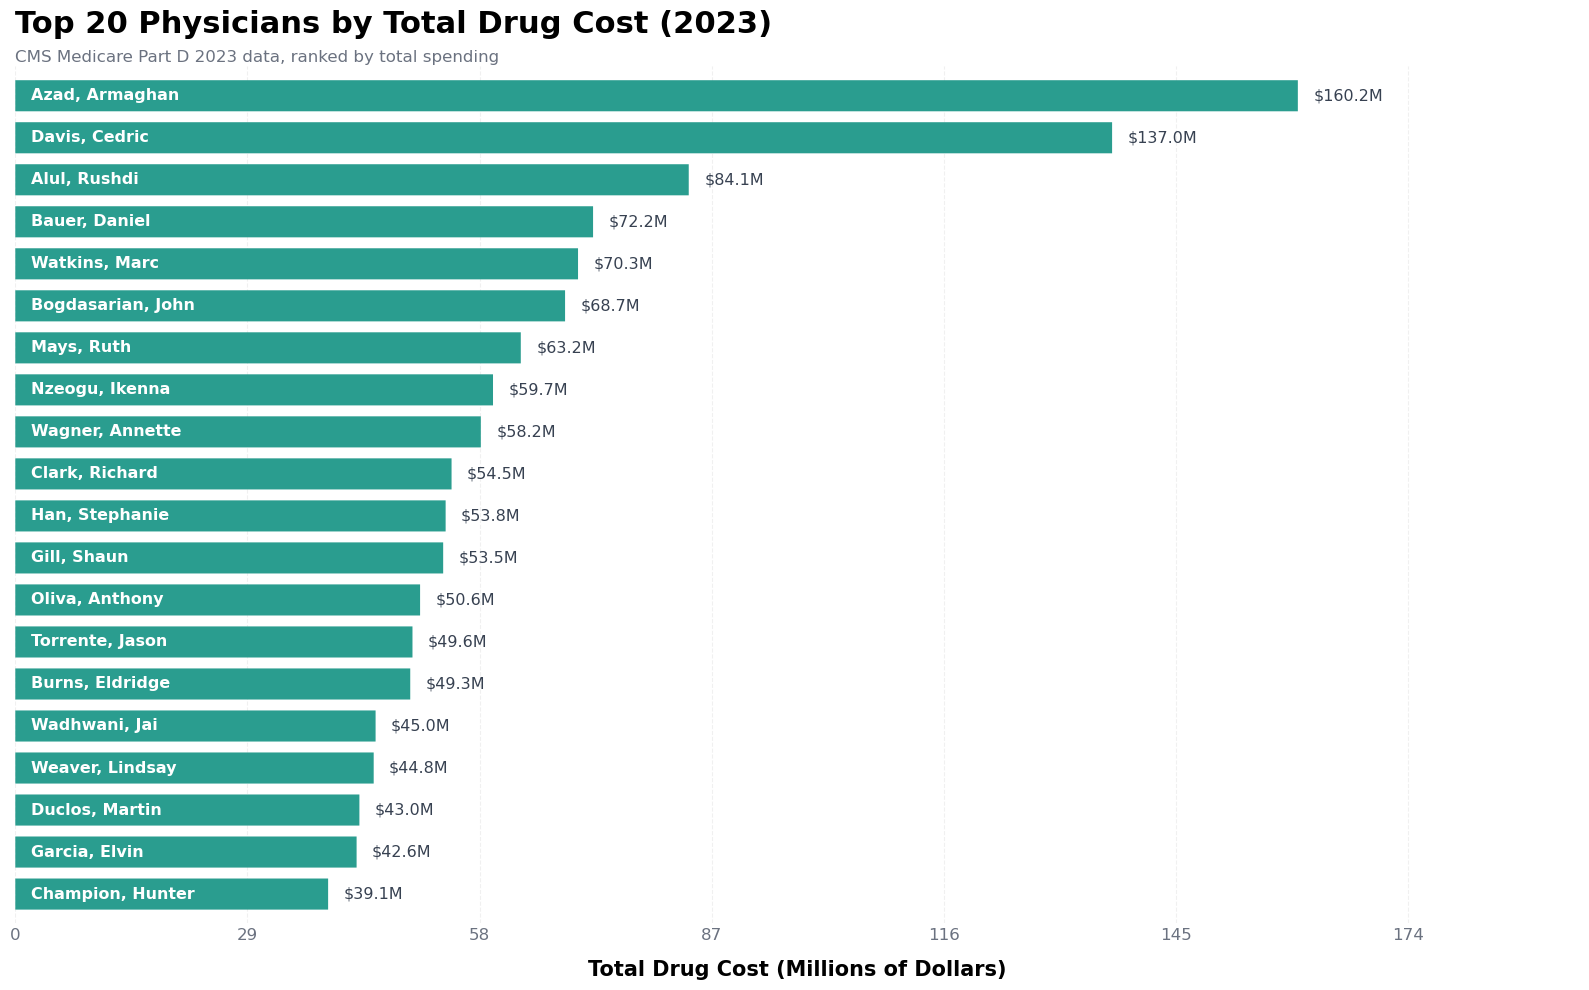

,Prscrbr_NPI,Physician,Prscrbr_Type,Total Drug Cost ($)
0,1639279417,"Azad, Armaghan",Emergency Medicine,1.602337e+08
1,1356534994,"Davis, Cedric",Family Practice,1.370274e+08
2,1649365529,"Alul, Rushdi",Internal Medicine,8.413488e+07
3,1992764591,"Bauer, Daniel",Internal Medicine,7.218143e+07
4,1972641074,"Watkins, Marc",Preventive Medicine,7.030360e+07
5,1265429617,"Bogdasarian, John",Otolaryngology,6.868380e+07
6,1003840778,"Mays, Ruth",Family Practice,6.315151e+07
7,1821068420,"Nzeogu, Ikenna",Family Practice,5.968132e+07
8,1699718031,"Wagner, Annette",Obstetrics & Gynecology,5.815900e+07
9,1053316364,"Clark, Richard",Family Practice,5.450225e+07


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import FancyBboxPatch

csv_path = Path("MUP_DPR_2023.csv")

if not csv_path.exists():
    raise FileNotFoundError("MUP_DPR_2023.csv not found in the project folder.")

chunks = []
usecols = [
    "Prscrbr_NPI",
    "Prscrbr_First_Name",
    "Prscrbr_Last_Org_Name",
    "Prscrbr_Type",
    "Tot_Drug_Cst",
]

for chunk in pd.read_csv(csv_path, usecols=usecols, chunksize=250_000, low_memory=False):
    chunk["Tot_Drug_Cst"] = pd.to_numeric(chunk["Tot_Drug_Cst"], errors="coerce").fillna(0)

    first = chunk["Prscrbr_First_Name"].fillna("").str.strip()
    last_org = chunk["Prscrbr_Last_Org_Name"].fillna("").str.strip()

    chunk["Physician"] = np.where(
        first.ne(""),
        last_org + ", " + first,
        last_org
    )

    chunk = chunk.loc[chunk["Physician"].ne("")].copy()

    grouped = (
        chunk.groupby(["Prscrbr_NPI", "Physician", "Prscrbr_Type"], as_index=False)["Tot_Drug_Cst"]
        .sum()
    )
    chunks.append(grouped)

physician_costs = (
    pd.concat(chunks, ignore_index=True)
    .groupby(["Prscrbr_NPI", "Physician", "Prscrbr_Type"], as_index=False)["Tot_Drug_Cst"]
    .sum()
    .sort_values("Tot_Drug_Cst", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

physician_costs = physician_costs.rename(columns={"Tot_Drug_Cst": "Total Drug Cost ($)"})

bar_df = physician_costs.sort_values("Total Drug Cost ($)", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 10), facecolor="white")
ax.set_facecolor("white")

y_pos = np.arange(len(bar_df))
bar_height = 0.72
bar_color = "#2A9D8F"

for y, value in zip(y_pos, bar_df["Total Drug Cost ($)"]):
    rounded_bar = FancyBboxPatch(
        (0, y - bar_height / 2),
        value,
        bar_height,
        boxstyle="round,pad=0.01,rounding_size=8",
        linewidth=0,
        facecolor=bar_color,
        zorder=3
    )
    ax.add_patch(rounded_bar)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.tick_params(axis="y", length=0, labelleft=False)
ax.tick_params(axis="x", length=0, labelsize=12, colors="#6B7280")
ax.grid(axis="x", linestyle="--", alpha=0.18, zorder=0)

ax.set_title(
    "Top 20 Physicians by Total Drug Cost (2023)",
    fontsize=22,
    fontweight="bold",
    loc="left",
    pad=24
)
ax.text(
    0, 1.005,
    "CMS Medicare Part D 2023 data, ranked by total spending",
    transform=ax.transAxes,
    fontsize=12,
    color="#6B7280"
)

ax.set_xlabel(
    "Total Drug Cost (Millions of Dollars)",
    fontsize=15,
    fontweight="bold",
    labelpad=12
)

max_val = bar_df["Total Drug Cost ($)"].max()
ax.set_xlim(0, max_val * 1.22)

tick_max_m = int(np.ceil((max_val * 1.05) / 1e6))
tick_step = max(1, int(np.ceil(tick_max_m / 6)))
tick_vals_m = np.arange(0, tick_max_m + tick_step, tick_step)

ax.set_xticks(tick_vals_m * 1e6)
ax.set_xticklabels([f"{v:,}" for v in tick_vals_m])

for y, physician, specialty, value in zip(
    y_pos,
    bar_df["Physician"],
    bar_df["Prscrbr_Type"],
    bar_df["Total Drug Cost ($)"]
):
    ax.text(
        max_val * 0.012,
        y,
        physician,
        va="center",
        ha="left",
        fontsize=11.5,
        fontweight="bold",
        color="white"
    )
    ax.text(
        value + max_val * 0.012,
        y,
        f"${value/1e6:,.1f}M",
        va="center",
        ha="left",
        fontsize=11.5,
        color="#374151"
    )

ax.set_yticks(y_pos)
ax.set_yticklabels([])
ax.set_ylim(-0.7, len(bar_df) - 0.3)

plt.tight_layout()
plt.show()

physician_costs.head(20)


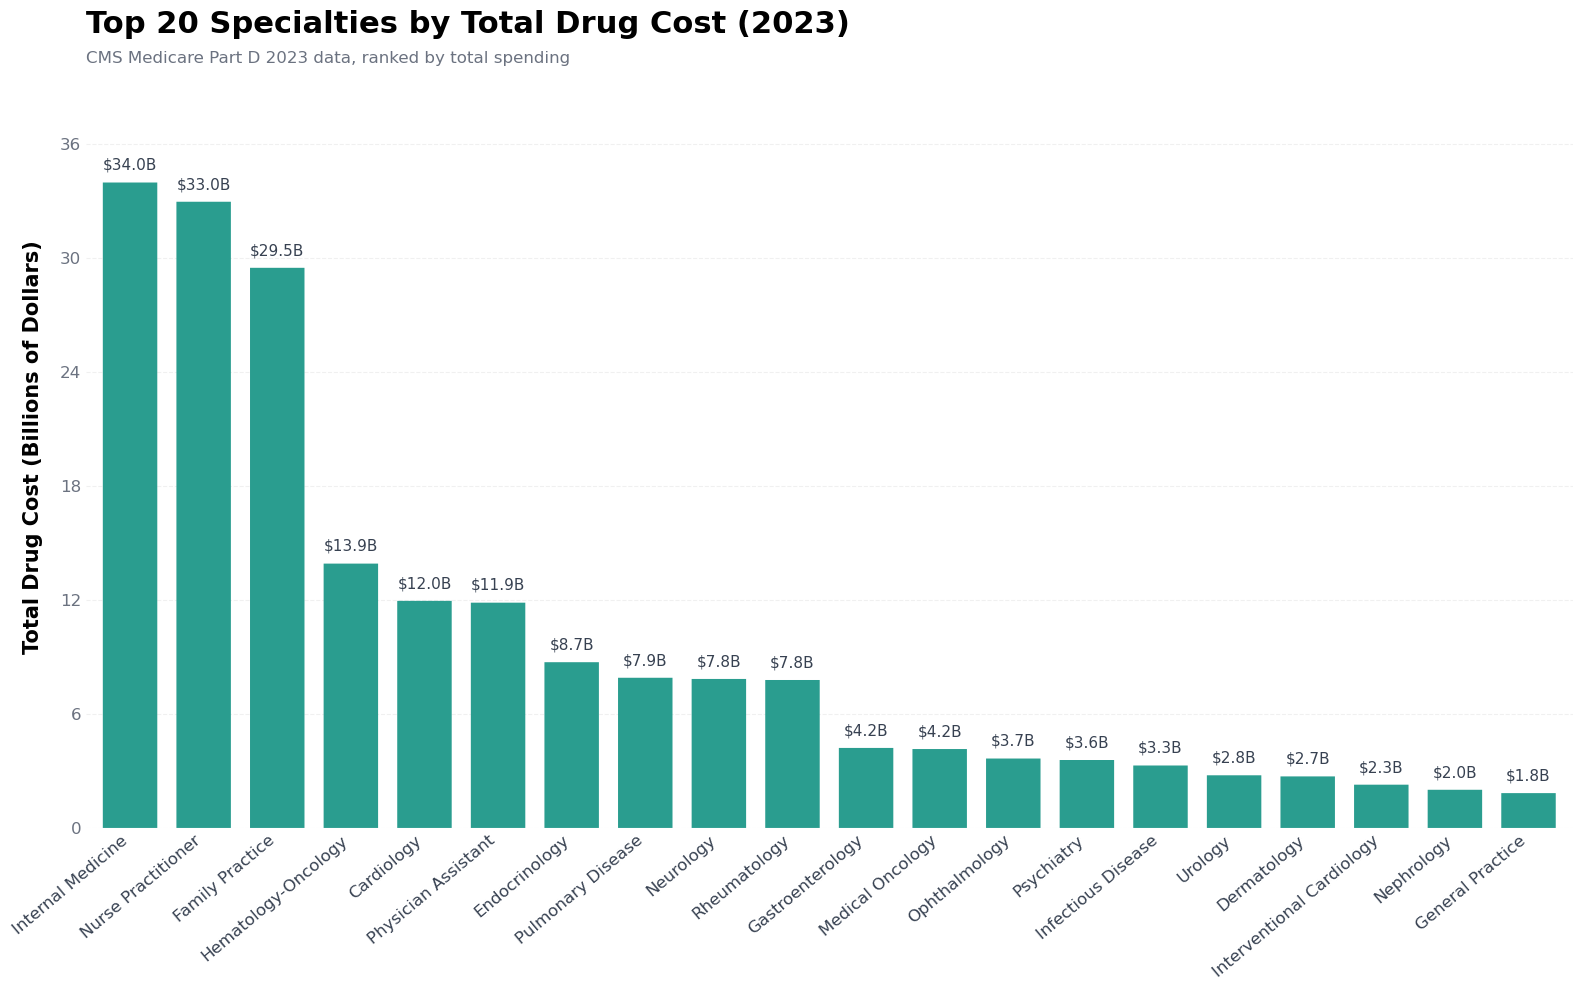

,Specialty,Total Drug Cost ($)
0,Internal Medicine,3.398838e+10
1,Nurse Practitioner,3.297548e+10
2,Family Practice,2.949658e+10
3,Hematology-Oncology,1.391991e+10
4,Cardiology,1.195811e+10
5,Physician Assistant,1.186239e+10
6,Endocrinology,8.727670e+09
7,Pulmonary Disease,7.908221e+09
8,Neurology,7.845843e+09
9,Rheumatology,7.790991e+09


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import FancyBboxPatch

csv_path = Path("MUP_DPR_2023.csv")

if not csv_path.exists():
    raise FileNotFoundError("MUP_DPR_2023.csv not found.")

specialty_totals = pd.Series(dtype="float64")

for chunk in pd.read_csv(
    csv_path,
    usecols=["Prscrbr_Type", "Tot_Drug_Cst"],
    chunksize=250_000,
    low_memory=False
):
    chunk["Tot_Drug_Cst"] = pd.to_numeric(chunk["Tot_Drug_Cst"], errors="coerce").fillna(0)
    chunk["Prscrbr_Type"] = chunk["Prscrbr_Type"].fillna("").str.strip()
    chunk = chunk.loc[chunk["Prscrbr_Type"].ne("")]

    chunk_totals = chunk.groupby("Prscrbr_Type")["Tot_Drug_Cst"].sum()
    specialty_totals = specialty_totals.add(chunk_totals, fill_value=0)

plot_df = (
    specialty_totals.sort_values(ascending=False)
    .head(20)
    .reset_index()
)
plot_df.columns = ["Specialty", "Total Drug Cost ($)"]

fig, ax = plt.subplots(figsize=(16, 10), facecolor="white")
ax.set_facecolor("white")

x = np.arange(len(plot_df))
bar_width = 0.72
bar_color = "#2A9D8F"
max_val = plot_df["Total Drug Cost ($)"].max()

for xi, value in zip(x, plot_df["Total Drug Cost ($)"]):
    rounded_bar = FancyBboxPatch(
        (xi - bar_width / 2, 0),
        bar_width,
        value,
        boxstyle="round,pad=0.01,rounding_size=8",
        linewidth=0,
        facecolor=bar_color,
        zorder=3
    )
    ax.add_patch(rounded_bar)

    ax.text(
        xi,
        value + max_val * 0.015,
        f"${value/1e9:,.1f}B",
        ha="center",
        va="bottom",
        fontsize=11,
        color="#374151"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

ax.grid(axis="y", linestyle="--", alpha=0.18, zorder=0)
ax.tick_params(axis="x", length=0, labelsize=12, colors="#374151")
ax.tick_params(axis="y", length=0, labelsize=12, colors="#6B7280")

ax.set_title(
    "Top 20 Specialties by Total Drug Cost (2023)",
    fontsize=22,
    fontweight="bold",
    loc="left",
    pad=24
)
ax.text(
    0, 1.005,
    "CMS Medicare Part D 2023 data, ranked by total spending",
    transform=ax.transAxes,
    fontsize=12,
    color="#6B7280"
)

ax.set_ylabel(
    "Total Drug Cost (Billions of Dollars)",
    fontsize=15,
    fontweight="bold",
    labelpad=12
)

tick_max_b = int(np.ceil((max_val * 1.05) / 1e9))
tick_step = max(1, int(np.ceil(tick_max_b / 6)))
tick_vals_b = np.arange(0, tick_max_b + tick_step, tick_step)

ax.set_yticks(tick_vals_b * 1e9)
ax.set_yticklabels([f"{v:,}" for v in tick_vals_b])

ax.set_xticks(x)
ax.set_xticklabels(plot_df["Specialty"], rotation=40, ha="right")
ax.set_xlim(-0.6, len(plot_df) - 0.4)
ax.set_ylim(0, max_val * 1.18)

plt.tight_layout()
plt.show()

plot_df
